# Belief State Geometry

Show the fractals...

In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px

import torch as t
from pca import load_pca_results, plot_in_simplex, visualize_simplex_3D

In [2]:
results = load_pca_results(save_dir="pca_results", run_id="20251207_232030")
metrics_df = results['metrics']
regressors = results['regressors']
data = results['data']  # Contains 'targets', 'layer_0_activations', 'layer_0_predictions', etc.

print(metrics_df)

Loaded metrics from pca_results/20251207_232030_metrics.csv
Loaded regressors from pca_results/20251207_232030_regressors.pkl
Loaded data from pca_results/20251207_232030_data.npz
  Available keys: ['targets', 'layer_0_activations', 'layer_0_predictions', 'layer_1_activations', 'layer_1_predictions', 'layer_2_activations', 'layer_2_predictions', 'layer_3_activations', 'layer_3_predictions']
   layer       mse  r2_score  baseline_mse
0      0  0.000666  0.995982      0.165787
1      1  0.000542  0.996731      0.165787
2      2  0.000410  0.997525      0.165787
3      3  0.000289  0.998258      0.165787


In [3]:
np.sum((data['layer_1_predictions'] - data['targets']) ** 2, axis=1).mean()

np.float64(0.0016257051267156855)

(<Figure size 1000x1000 with 1 Axes>,
 <Axes: title={'center': '3-Simplex Visualization'}>)

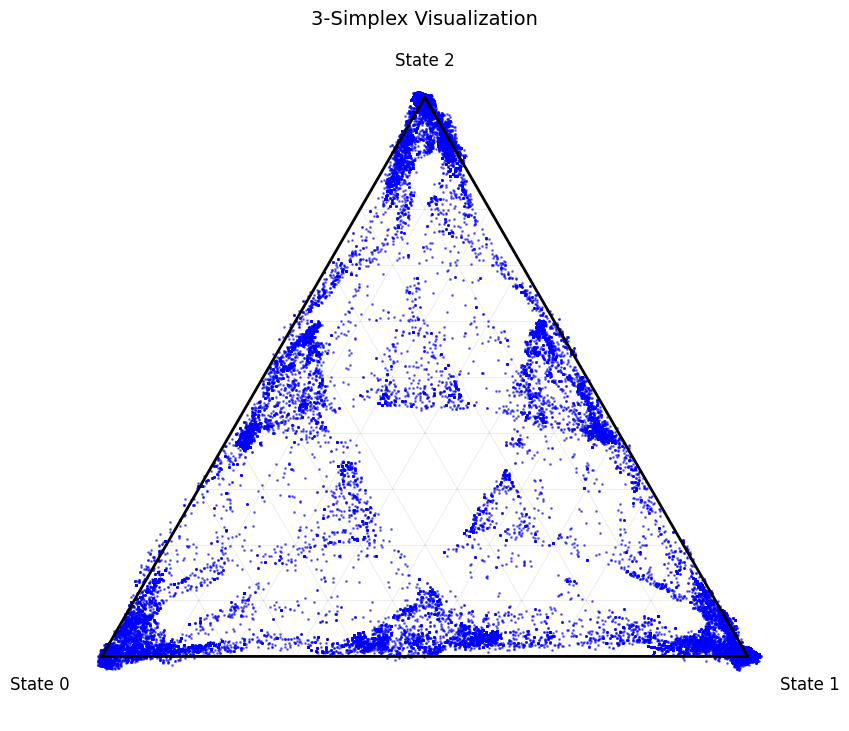

In [7]:
plot_in_simplex(data['layer_3_predictions'])

[0.00253549 0.00251241 0.00253272]


(<Figure size 1000x1000 with 1 Axes>,
 <Axes: title={'center': '3-Simplex Visualization'}>)

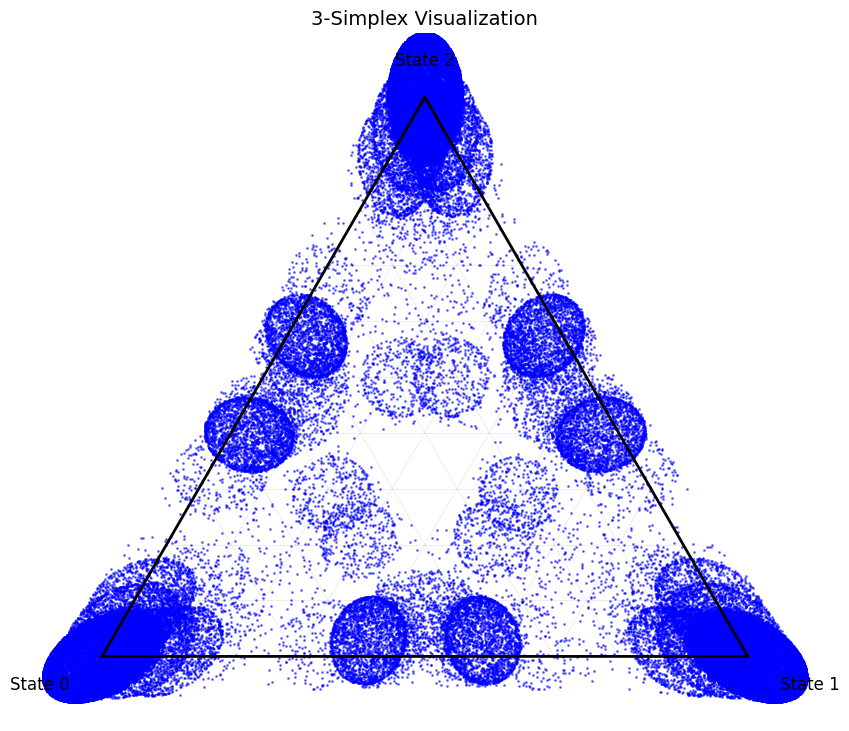

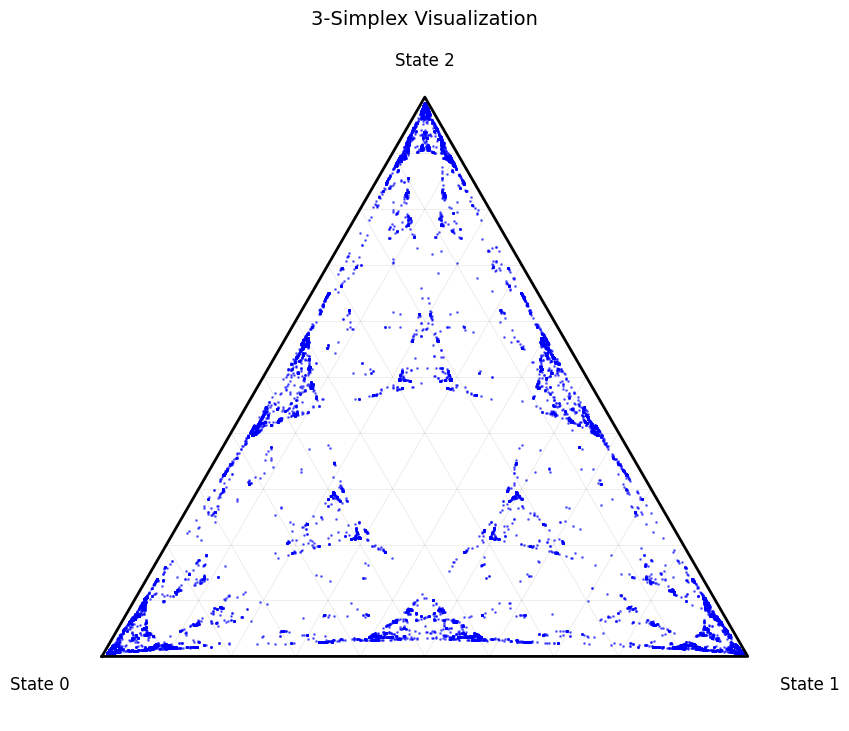

In [59]:
perturbations = np.random.randn(data['targets'].shape[0], data['targets'].shape[1])
perturbations = perturbations / np.linalg.norm(perturbations, axis=1, keepdims=True)
perturbations *= 0.08
baseline_data = data['targets'] + perturbations
baseline_data = baseline_data / np.sum(baseline_data, axis=1, keepdims=True)
mse = np.mean((baseline_data - data['targets']) ** 2, axis=0)
print(mse)
plot_in_simplex(baseline_data)
plot_in_simplex(data['targets'])

